In [1]:
import pandas as pd 

In [8]:
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1,22)] 
col_names = index_names + setting_names + sensor_names
test_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/test_FD001.txt",sep='\s+', header=None, names=col_names)
train_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/train_FD001.txt",sep='\s+', header=None, names=col_names)
RUL_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/RUL_FD001.txt",sep='\s+', header=None, names=['RUL'])

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ws/ry5x1yk962x496923v2x8q0c0000gn/T/ipykernel_59464/33335935.py:5: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/test_FD001.txt",sep='\s+', header=None, names=col_names)
/var/folders/ws/ry5x1yk962x496923v2x8q0c0000gn/T/ipykernel_59464/33335935.py:6: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv("/Users/seanhackenberg/School/Case Studies in ML/case-studies-ml-project-rul/data/train_FD001.txt",sep='\s+', header=None, names=col_names)
/var/folders/ws/ry5x1yk962x496923v2x8q0c0000gn/T/ipykernel_59464/33335935.py:7: SyntaxWarning: invalid escape sequence '\s'


In [11]:
test_df.describe()
print(test_df.shape)
cols_to_drop = [col for col in test_df.columns]
# Identify constant columns
constant_columns = test_df.columns[test_df.nunique(dropna=False) == 1]

# Drop the constant columns
test_df_cleaned = test_df.drop(columns=constant_columns)
train_df_cleaned = train_df.drop(columns=constant_columns)
test_df_cleaned


(13096, 26)


,unit_nr,time_cycles,setting_1,setting_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,643.24,1599.45,1415.79,21.61,553.41,2388.02,9142.37,47.69,520.69,2388.00,8213.28,8.4715,394,38.65,23.1974
13092,100,195,-0.0011,-0.0001,643.22,1595.69,1422.05,21.61,553.22,2388.05,9140.68,47.60,521.05,2388.09,8210.85,8.4512,395,38.57,23.2771
13093,100,196,-0.0006,-0.0003,643.44,1593.15,1406.82,21.61,553.04,2388.11,9146.81,47.57,521.18,2388.04,8217.24,8.4569,395,38.62,23.2051
13094,100,197,-0.0038,0.0001,643.26,1594.99,1419.36,21.61,553.37,2388.07,9148.85,47.61,521.33,2388.08,8220.48,8.4711,395,38.66,23.2699


In [13]:
test_df_cleaned.corr()

,unit_nr,time_cycles,setting_1,setting_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
unit_nr,1.000000,0.033629,-0.018456,0.002970,0.074428,0.062619,0.094717,0.025681,-0.093310,0.080592,0.044873,0.103683,-0.093578,0.081118,0.024729,0.084479,0.082390,-0.090654,-0.081445
time_cycles,0.033629,1.000000,-0.003184,-0.020543,0.348094,0.322121,0.428697,0.076825,-0.404598,0.312229,0.340687,0.446071,-0.416962,0.310481,0.257984,0.385036,0.361176,-0.384333,-0.376825
setting_1,-0.018456,-0.003184,1.000000,-0.007701,0.007159,0.000522,-0.002406,-0.008338,0.000436,0.000401,-0.002734,0.004653,-0.006223,0.011649,-0.008583,0.006341,-0.002448,-0.003114,0.007560
setting_2,0.002970,-0.020543,-0.007701,1.000000,-0.019323,-0.014673,-0.023242,-0.013166,0.028616,-0.025603,0.016284,-0.031544,0.025507,-0.034281,0.023701,-0.019879,-0.007585,0.007039,0.028477
s_2,0.074428,0.348094,0.007159,-0.019323,1.000000,0.387655,0.540813,0.122260,-0.526991,0.526649,0.025602,0.570150,-0.560245,0.527775,-0.086211,0.496486,0.423478,-0.475045,-0.466920
s_3,0.062619,0.322121,0.000522,-0.014673,0.387655,1.000000,0.467417,0.101223,-0.481640,0.451400,0.072343,0.503727,-0.489609,0.447226,-0.029337,0.427995,0.379133,-0.413866,-0.409713
s_4,0.094717,0.428697,-0.002406,-0.023242,0.540813,0.467417,1.000000,0.142806,-0.650700,0.635391,0.029533,0.687747,-0.675109,0.631043,-0.105956,0.589177,0.517864,-0.577188,-0.562496
s_6,0.025681,0.076825,-0.008338,-0.013166,0.122260,0.101223,0.142806,1.000000,-0.152301,0.147120,-0.016622,0.161171,-0.158954,0.158220,-0.054378,0.137836,0.121726,-0.130280,-0.139532
s_7,-0.093310,-0.404598,0.000436,0.028616,-0.526991,-0.481640,-0.650700,-0.152301,1.000000,-0.657311,0.029193,-0.694869,0.683309,-0.657077,0.166849,-0.591034,-0.519374,0.569468,0.564581
s_8,0.080592,0.312229,0.000401,-0.025603,0.526649,0.451400,0.635391,0.147120,-0.657311,1.000000,-0.247761,0.684848,-0.685651,0.719693,-0.387148,0.574910,0.494086,-0.561075,-0.561457


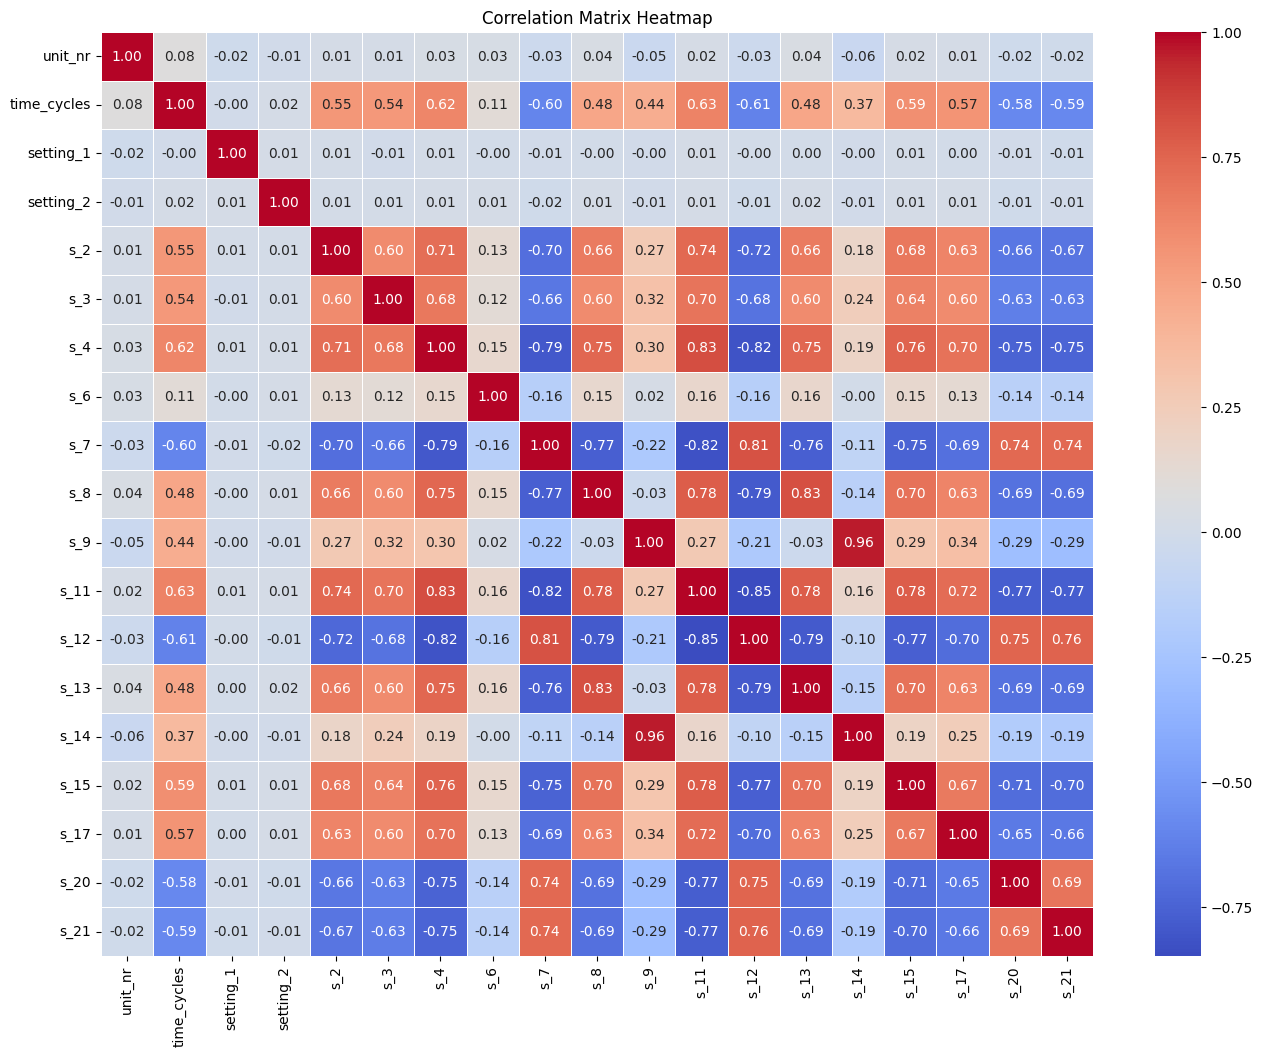

In [15]:
import seaborn as sns
from matplotlib import pyplot as plt

plt.figure(figsize=(16, 12)) # Adjust figure size as needed
sns.heatmap(train_df_cleaned.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [16]:
test_df_cleaned.describe()


,unit_nr,time_cycles,setting_1,setting_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000
mean,51.543907,76.836515,-0.000011,0.000004,642.475088,1588.099204,1404.735362,21.609701,553.757523,2388.070964,9058.407363,47.416204,521.747724,2388.071025,8138.947817,8.425844,392.571625,38.892502,23.335743
std,28.289423,53.057749,0.002203,0.000294,0.400899,5.003274,6.688309,0.001704,0.681286,0.057442,11.436261,0.195917,0.559627,0.056934,10.188605,0.029009,1.233577,0.141681,0.084120
min,1.000000,1.000000,-0.008200,-0.000600,641.130000,1569.040000,1384.390000,21.600000,550.880000,2387.890000,9024.530000,46.800000,519.380000,2387.890000,8108.500000,8.332800,389.000000,38.310000,22.935400
25%,28.000000,33.000000,-0.001500,-0.000200,642.197500,1584.600000,1399.950000,21.610000,553.310000,2388.030000,9051.020000,47.270000,521.380000,2388.030000,8132.310000,8.405600,392.000000,38.800000,23.281600
50%,52.000000,69.000000,-0.000000,-0.000000,642.460000,1587.990000,1404.440000,21.610000,553.800000,2388.070000,9057.320000,47.410000,521.780000,2388.070000,8138.390000,8.424900,393.000000,38.900000,23.339200
75%,76.000000,113.000000,0.001500,0.000300,642.740000,1591.362500,1409.050000,21.610000,554.240000,2388.110000,9064.110000,47.540000,522.150000,2388.110000,8144.360000,8.444300,393.000000,38.990000,23.393600
max,100.000000,303.000000,0.007800,0.000700,644.300000,1607.550000,1433.360000,21.610000,555.840000,2388.300000,9155.030000,48.260000,523.760000,2388.320000,8220.480000,8.541400,397.000000,39.410000,23.641900


<Axes: >

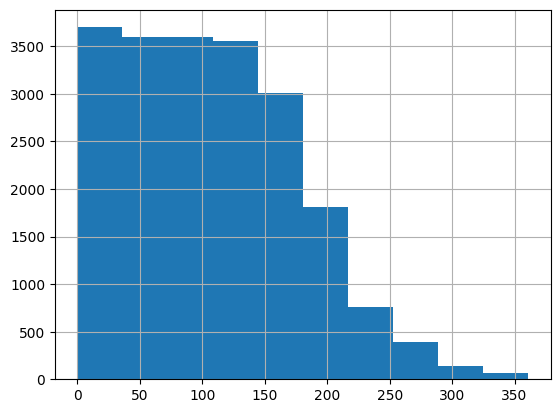

In [35]:
def add_remaining_useful_life(df):
    # Get the total number of cycles for each unit
    grouped_by_unit = df.groupby(by="unit_nr")
    max_cycle = grouped_by_unit["time_cycles"].max()
    
    # Merge the max cycle back into the original frame
    result_frame = df.merge(max_cycle.to_frame(name='max_cycle'), left_on='unit_nr', right_index=True)
    
    # Calculate remaining useful life for each row
    remaining_useful_life = result_frame["max_cycle"] - result_frame["time_cycles"]
    result_frame["RUL"] = remaining_useful_life
    
    # drop max_cycle as it's no longer needed
    result_frame = result_frame.drop("max_cycle", axis=1)
    return result_frame

train = add_remaining_useful_life(train_df_cleaned)
test = add_remaining_useful_life(test_df_cleaned)
train["RUL"].hist()

In [36]:
train.groupby("unit_nr")["RUL"].max().describe()

count    100.000000
mean     205.310000
std       46.342749
min      127.000000
25%      176.000000
50%      198.000000
75%      228.250000
max      361.000000
Name: RUL, dtype: float64

In [37]:
capped_train = train.copy()
capped_test = test.copy()
capped_train["RUL"] = capped_train["RUL"].apply(lambda x: 150 if x >= 150 else x)
capped_test["RUL"] = capped_test["RUL"].apply(lambda x: 150 if x >= 150 else x)
capped_train["RUL"].describe()

count    20631.000000
mean        95.134361
std         49.971670
min          0.000000
25%         51.000000
50%        103.000000
75%        150.000000
max        150.000000
Name: RUL, dtype: float64

In [39]:
test

,unit_nr,time_cycles,setting_1,setting_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735,30
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916,29
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166,28
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737,27
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.0049,0.0000,643.24,1599.45,1415.79,21.61,553.41,2388.02,9142.37,47.69,520.69,2388.00,8213.28,8.4715,394,38.65,23.1974,4
13092,100,195,-0.0011,-0.0001,643.22,1595.69,1422.05,21.61,553.22,2388.05,9140.68,47.60,521.05,2388.09,8210.85,8.4512,395,38.57,23.2771,3
13093,100,196,-0.0006,-0.0003,643.44,1593.15,1406.82,21.61,553.04,2388.11,9146.81,47.57,521.18,2388.04,8217.24,8.4569,395,38.62,23.2051,2
13094,100,197,-0.0038,0.0001,643.26,1594.99,1419.36,21.61,553.37,2388.07,9148.85,47.61,521.33,2388.08,8220.48,8.4711,395,38.66,23.2699,1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Load your data (adjust file paths as needed)
train_data = capped_train
test_data = capped_test

# Remove engine ID and cycle number, keep only sensor features and RUL
X_train = train_data.drop(['unit_nr', 'time_cycles', 'RUL'], axis=1)
y_train = train_data['RUL']

X_test = test_data.drop(['unit_nr', 'time_cycles', 'RUL'], axis=1)
y_test = test_data['RUL']


scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Evaluate on training set
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

# Evaluate on test set
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

# Print results
print("Training Results:")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  MAE:  {train_mae:.2f}")
print(f"  R²:   {train_r2:.4f}")

print("\nTest Results:")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  MAE:  {test_mae:.2f}")
print(f"  R²:   {test_r2:.4f}")

# Optional: Print feature importance (coefficients)
print("\nFeature Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef:.6f}")

Training Results:
  RMSE: 27.30
  MAE:  22.25
  R²:   0.7015

Test Results:
  RMSE: 60.86
  MAE:  50.42
  R²:   -0.7021

Feature Coefficients:
  setting_1: 0.027715
  setting_2: 0.179764
  s_2: -2.592390
  s_3: -2.008918
  s_4: -5.123492
  s_6: 0.610636
  s_7: 5.027870
  s_8: -1.005369
  s_9: -6.762484
  s_11: -7.385381
  s_12: 6.243681
  s_13: -1.253039
  s_14: -4.835184
  s_15: -3.714049
  s_17: -2.384627
  s_20: 3.018341
  s_21: 3.027983


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

scaler = StandardScaler()

# Load your data (adjust file paths as needed)
train_data = capped_train
test_data = capped_test

# Remove engine ID and cycle number, keep only sensor features and RUL
X_train = train_data.drop(['unit_nr', 'time_cycles', 'RUL'], axis=1)
y_train = train_data['RUL']

X_test = test_data.drop(['unit_nr', 'time_cycles', 'RUL'], axis=1)
y_test = test_data['RUL']

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========== RANDOM FOREST ==========
print("=" * 50)
print("RANDOM FOREST REGRESSOR")
print("=" * 50)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
rf_y_pred_train = rf_model.predict(X_train_scaled)
rf_y_pred_test = rf_model.predict(X_test_scaled)

# Evaluate Random Forest
rf_train_mse = mean_squared_error(y_train, rf_y_pred_train)
rf_train_rmse = np.sqrt(rf_train_mse)
rf_train_mae = mean_absolute_error(y_train, rf_y_pred_train)
rf_train_r2 = r2_score(y_train, rf_y_pred_train)

rf_test_mse = mean_squared_error(y_test, rf_y_pred_test)
rf_test_rmse = np.sqrt(rf_test_mse)
rf_test_mae = mean_absolute_error(y_test, rf_y_pred_test)
rf_test_r2 = r2_score(y_test, rf_y_pred_test)

print("\nTraining Results:")
print(f"  RMSE: {rf_train_rmse:.2f}")
print(f"  MAE:  {rf_train_mae:.2f}")
print(f"  R²:   {rf_train_r2:.4f}")

print("\nTest Results:")
print(f"  RMSE: {rf_test_rmse:.2f}")
print(f"  MAE:  {rf_test_mae:.2f}")
print(f"  R²:   {rf_test_r2:.4f}")

# Feature importance for Random Forest
print("\nTop 10 Important Features (Random Forest):")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10).to_string(index=False))



RANDOM FOREST REGRESSOR

Training Results:
  RMSE: 11.54
  MAE:  8.63
  R²:   0.9466

Test Results:
  RMSE: 62.11
  MAE:  50.69
  R²:   -0.7726

Top 10 Important Features (Random Forest):
feature  importance
   s_11    0.552904
    s_9    0.133380
    s_4    0.072550
   s_12    0.044841
   s_14    0.028481
    s_7    0.027785
   s_15    0.021999
   s_21    0.018634
    s_3    0.016887
    s_2    0.016585


In [46]:
# ========== XGBOOST ==========
print("\n" + "=" * 50)
print("XGBOOST REGRESSOR")
print("=" * 50)

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)

# Predictions
xgb_y_pred_train = xgb_model.predict(X_train_scaled)
xgb_y_pred_test = xgb_model.predict(X_test_scaled)

# Evaluate XGBoost
xgb_train_mse = mean_squared_error(y_train, xgb_y_pred_train)
xgb_train_rmse = np.sqrt(xgb_train_mse)
xgb_train_mae = mean_absolute_error(y_train, xgb_y_pred_train)
xgb_train_r2 = r2_score(y_train, xgb_y_pred_train)

xgb_test_mse = mean_squared_error(y_test, xgb_y_pred_test)
xgb_test_rmse = np.sqrt(xgb_test_mse)
xgb_test_mae = mean_absolute_error(y_test, xgb_y_pred_test)
xgb_test_r2 = r2_score(y_test, xgb_y_pred_test)

print("\nTraining Results:")
print(f"  RMSE: {xgb_train_rmse:.2f}")
print(f"  MAE:  {xgb_train_mae:.2f}")
print(f"  R²:   {xgb_train_r2:.4f}")

print("\nTest Results:")
print(f"  RMSE: {xgb_test_rmse:.2f}")
print(f"  MAE:  {xgb_test_mae:.2f}")
print(f"  R²:   {xgb_test_r2:.4f}")

# Feature importance for XGBoost
print("\nTop 10 Important Features (XGBoost):")
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print(xgb_importance.head(10).to_string(index=False))


XGBOOST REGRESSOR

Training Results:
  RMSE: 20.27
  MAE:  15.29
  R²:   0.8354

Test Results:
  RMSE: 62.67
  MAE:  51.02
  R²:   -0.8048

Top 10 Important Features (XGBoost):
feature  importance
   s_11    0.428335
    s_4    0.180944
   s_12    0.093861
    s_9    0.084655
   s_14    0.037544
    s_7    0.029181
   s_15    0.024871
   s_13    0.021813
   s_17    0.021465
   s_21    0.016016


In [47]:
# ========== MODEL COMPARISON ==========
print("\n" + "=" * 50)
print("MODEL COMPARISON (Test Set)")
print("=" * 50)
print(f"\n{'Model':<15} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
print("-" * 51)
print(f"{'Random Forest':<15} {rf_test_rmse:<12.2f} {rf_test_mae:<12.2f} {rf_test_r2:<12.4f}")
print(f"{'XGBoost':<15} {xgb_test_rmse:<12.2f} {xgb_test_mae:<12.2f} {xgb_test_r2:<12.4f}")


MODEL COMPARISON (Test Set)

Model           RMSE         MAE          R²          
---------------------------------------------------
Random Forest   62.11        50.69        -0.7726     
XGBoost         62.67        51.02        -0.8048     


In [48]:
y_train.describe()

count    20631.000000
mean        95.134361
std         49.971670
min          0.000000
25%         51.000000
50%        103.000000
75%        150.000000
max        150.000000
Name: RUL, dtype: float64